In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/karyo-wise

/content/drive/MyDrive/karyo-wise


In [ ]:
!pip install -r requirements.txt

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-ub27xsp6
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-ub27xsp6
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
Obtaining file:///content/drive/MyDrive/karyo-wise (from -r requirements.txt (line 27))
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 kB 3.3 MB/s eta 0:00:00
  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.2 MB/s eta 0:00:00
   ━

In [ ]:
from segment_anything import SamPredictor, sam_model_registry, SamAutomaticMaskGenerator
from pathlib import Path
from PIL import Image
from matplotlib import pyplot as plt
import cv2
import numpy as np
import torch

%load_ext autoreload
%autoreload 2
from karyo_wise.config import RAW_DATA_DIR_IMG, EXTERNAL_DATA_DIR, SAM_WEIGHTS, RAW_DATA_DIR_ANN
from karyo_wise.plots import show_masks_and_boxes
from karyo_wise.dataset import parse_voc_xml_to_bounding_box

%matplotlib inline

ModuleNotFoundError: No module named 'segment_anything'

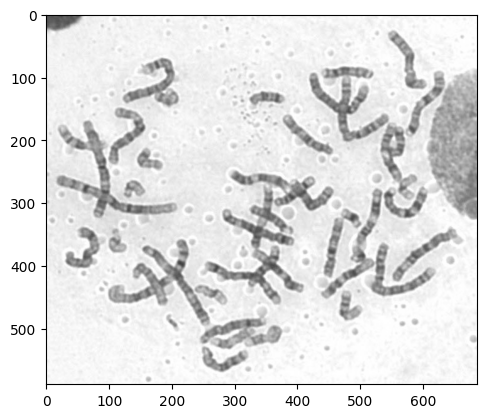

In [ ]:
path = Path(RAW_DATA_DIR_IMG)
img_path = next(path.iterdir())
img_id = img_path.stem
img_ori = cv2.imread(img_path)
plt.imshow(img_ori)

In [ ]:
# !wget -P {EXTERNAL_DATA_DIR} https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [ ]:
sam_checkpoint = SAM_WEIGHTS
model_type = "vit_h"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

/usr/local/lib/python3.10/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


In [ ]:
path = Path(RAW_DATA_DIR_ANN)
ann_path = f"{path}/{img_id}.xml"
print(img_path, "\n", ann_path)
boxes = parse_voc_xml_to_bounding_box(ann_path)
boxes_input = torch.tensor(boxes, device=predictor.device)

/content/drive/MyDrive/karyo-wise/data/raw/JEPG/1080801.jpg 
 /content/drive/MyDrive/karyo-wise/data/raw/annotations/1080801.xml


In [ ]:
img_rgb = cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB)
predictor.set_image(img_rgb)
transformed_boxes = predictor.transform.apply_boxes_torch(boxes_input, img_ori.shape[:2])
masks, iou_predictions, low_res_masks =  predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=True,
    mask_input=None,
    return_logits=False
)

In [ ]:
print(img_rgb.shape)
masks.shape

(589, 687, 3)


torch.Size([46, 3, 589, 687])

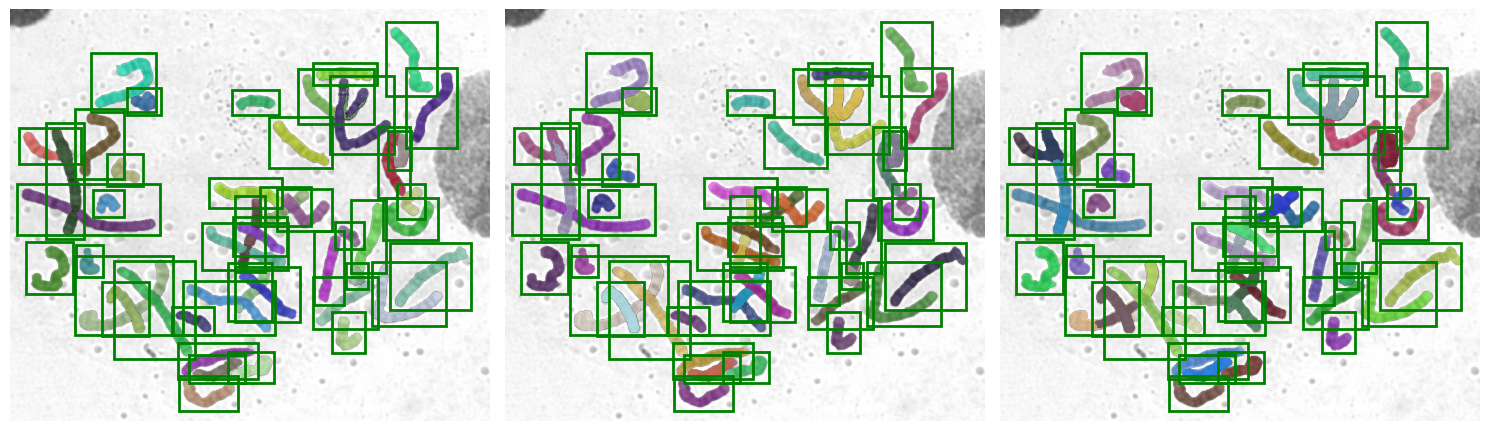

In [ ]:
show_masks_and_boxes(img_ori, masks, boxes)